<a href="https://colab.research.google.com/github/zydanne-costa/Correntometro_INFINITY-EM/blob/main/WaveSpectra_CHU_Chatgpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "wavespectra[extra]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.3/164.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 15.1 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=67a2bb29003d27417fa2bd5d7cfd28727a62c0629faed46327ab96f4329c7ccc
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.14.0
    Uninstalling tomlkit-0.14.0:
      Successfully uninstalled tomlkit-0.14.0
ERROR: pip's dependency resolver doe

In [15]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import wavespectra
from google.colab import drive

In [3]:
# ============================================================
# 1. Montar Google Drive
# ============================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# 2. Caminho dos arquivos DSpec
# ============================================================

caminho_diretorio = '/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/DSpec_2/'

arquivos = sorted(glob.glob(os.path.join(caminho_diretorio, "*.txt")))


print(f"Número de arquivos encontrados: {len(arquivos)}")

Número de arquivos encontrados: 442


In [45]:
# ============================================================
# 3. Ler todos os espectros e armazenar
# ============================================================

lista_espectros = []


for arquivo in arquivos:

    nome = os.path.basename(arquivo)

    # Ler matriz 64 x 90
    energia = np.loadtxt(arquivo, comments='%')
    energia = energia / 1e6

    lista_espectros.append(energia)


print("Arquivos carregados!")

Arquivos carregados!


In [46]:
# ============================================================
# 4. Transformar em matriz 3D
# ============================================================

# Dimensão:
# tempo x frequência x direção

espectros = np.array(lista_espectros)


print("Dimensão dos dados:")
print(espectros.shape)

Dimensão dos dados:
(442, 64, 90)


In [47]:
# ============================================================
# 5. Calcular espectro direcional médio do período
# ============================================================


espectro_medio = np.mean(espectros, axis=0)


print(espectro_medio.shape)

(64, 90)


In [48]:
# ============================================================
# 6. Criar coordenadas
# ============================================================

f0 = 0.00878906
df = 0.015625
frequencias = f0 + np.arange(64)*df

direcoes = np.linspace(0,360,90,endpoint=False)



# Criar DataArray

da = xr.DataArray(
    data=espectro_medio,
    dims=["freq","dir"],
    coords={
        "freq": frequencias,
        "dir": direcoes
    },
    name="efth"
)

Figura salva em:
/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/DSpec_2/Resultado_2D_DSPEC.png


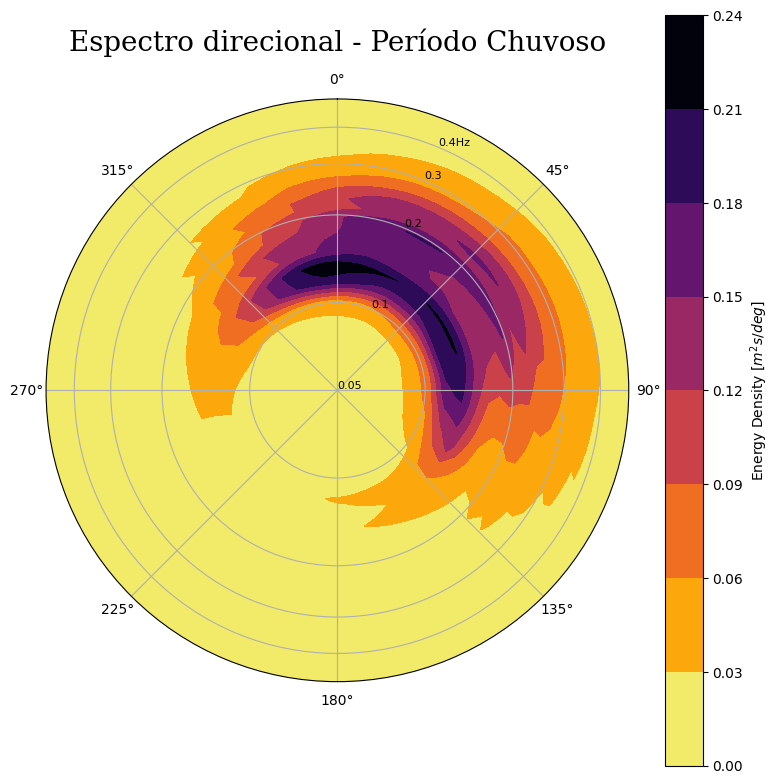

In [70]:
# ============================================================
# 7. Plotar espectro médio
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw={"projection":"polar"}
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

plt.sca(ax)


da.spec.plot(
    rmin=0.05,
    rmax=0.5,
    kind="contourf",
    as_period=False,
    normalised=False,
    cmap="inferno_r",
    add_colorbar=True
)


plt.title(
    "Espectro direcional - Período Chuvoso",
    font="serif",
    fontsize=20,
    pad=35
)


plt.tight_layout()


saida = os.path.join(
    caminho_diretorio,
    "Resultado_2D_DSPEC.png"
)


plt.savefig(
    saida,
    dpi=300,
    bbox_inches="tight"
)


print("Figura salva em:")
print(saida)


plt.show()